# Euler-Maruyama Discretization of SABR

If we take the continuous SABR SDE denoted as: 

$$dF_t = \alpha_t F_t^\beta dW_t^1$$

$$d\alpha_t = \nu \alpha_t dW_t^2$$

To apply Euler-Maruyama, we slice the time horizon ($T$) into tiny steps ($\Delta t$). At each step, we update the forward rate ($F$) and the volatility ($\alpha$) using random normal shocks ($Z$).

The discrete formulas look like this:

$$F_{i+1} = F_i + \alpha_i F_i^\beta \sqrt{\Delta t} Z_1$$

$$\alpha_{i+1} = \alpha_i + \nu \alpha_i \sqrt{\Delta t} Z_2$$

Because $dW_t^1$ and $dW_t^2$ are correlated by $\rho$, we cannot just draw two random numbers independently. We use a Cholesky decomposition trick to link them. We draw two independent standard normal numbers ($Z_1$ and $Z_3$), and construct the correlated shock ($Z_2$) like this:

$$Z_2 = \rho Z_1 + \sqrt{1 - \rho^2} Z_3$$

\subsection{The Correlation Trick}
To create two standard normal random variables $Z_1$ and $Z_2$ with a correlation of $\rho$, we start with two independent standard normal variables, $Z_1$ and $Z_3$, and apply this linear combination:
$$Z_2 = \rho Z_1 + \sqrt{1 - \rho^2} Z_3$$

Now, $Z_1$ and $Z_2$ are perfectly correlated by exactly $\rho$.

To prove this works, we need to verify two things about our new variable $Z_2$: 
- It must still be a standard normal variable (meaning its mean is 0 and its variance is 1).
- Its covariance (correlation) with $Z_1$ must equal $\rho$

### Checking the Variance

Because $Z_1$ and $Z_3$ are independent, their variances simply add up when we scale them. The variance of a scaled random variable $aX$ is $a^2 \text{Var}(X)$.

$$\text{Var}(Z_2) = \text{Var}\left(\rho Z_1 + \sqrt{1 - \rho^2} Z_3\right)$$

$$\text{Var}(Z_2) = \rho^2 \text{Var}(Z_1) + \left(\sqrt{1 - \rho^2}\right)^2 \text{Var}(Z_3)$$

Since $Z_1$ and $Z_3$ are standard normals, their variances are equal to 1:

$$\text{Var}(Z_2) = \rho^2(1) + (1 - \rho^2)(1)$$

$$\text{Var}(Z_2) = \rho^2 + 1 - \rho^2 = 1$$

This proves that the weird $\sqrt{1 - \rho^2}$ multiplier is mathematically required to ensure that $Z_2$ doesn't blow up or shrink—it keeps its variance perfectly equal to 1.

### Checking the Correlation

The correlation between $Z_1$ and $Z_2$ is defined as their expected product $\mathbb{E}[Z_1 Z_2]$ (since their means are 0).

$$\text{Corr}(Z_1, Z_2) = \mathbb{E}[Z_1 Z_2]$$

$$\text{Corr}(Z_1, Z_2) = \mathbb{E}\left[Z_1 \left(\rho Z_1 + \sqrt{1 - \rho^2} Z_3\right)\right]$$

$$\text{Corr}(Z_1, Z_2) = \rho \mathbb{E}[Z_1^2] + \sqrt{1 - \rho^2} \mathbb{E}[Z_1 Z_3]$$

Notice $\mathbb{E}[Z_1^2]$ is just the variance of $Z_1$, which is 1. Additionally, $\mathbb{E}[Z_1 Z_3]$ is the covariance of $Z_1$ and $Z_3$. Since they are completely independent, this is 0. Plugging those in:

$$\text{Corr}(Z_1, Z_2) = \rho(1) + \sqrt{1 - \rho^2}(0) = \rho$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_sabr_euler_maruyama(F0, alpha0, beta, rho, nu, T, N_steps, M_paths):
    """
    Simulates the SABR model using the Euler-Maruyama method.
    """
    dt = T / N_steps
    
    # Initialize arrays to store the paths
    F = np.zeros((N_steps + 1, M_paths))
    alpha = np.zeros((N_steps + 1, M_paths))
    
    # Set initial conditions
    F[0] = F0
    alpha[0] = alpha0
    
    for i in range(N_steps):
        # Generate independent standard normal shocks
        Z1 = np.random.standard_normal(M_paths)
        Z3 = np.random.standard_normal(M_paths)
        
        # Construct the correlated shock for volatility
        Z2 = rho * Z1 + np.sqrt(1 - rho**2) * Z3
        
        # Euler-Maruyama step for Volatility (Alpha)
        # We use np.maximum to prevent volatility from dropping below zero 
        # due to discretization errors.
        alpha[i+1] = np.maximum(alpha[i] + nu * alpha[i] * np.sqrt(dt) * Z2, 0)
        
        # Euler-Maruyama step for the Forward Rate (F)
        # We use np.maximum to apply an absorbing boundary at 0.
        # If F hits 0, it stays at 0 (or simply avoids complex number errors for F^beta).
        F_safe = np.maximum(F[i], 0) 
        F[i+1] = np.maximum(F_safe + alpha[i] * (F_safe**beta) * np.sqrt(dt) * Z1, 0)
        
    return F, alpha

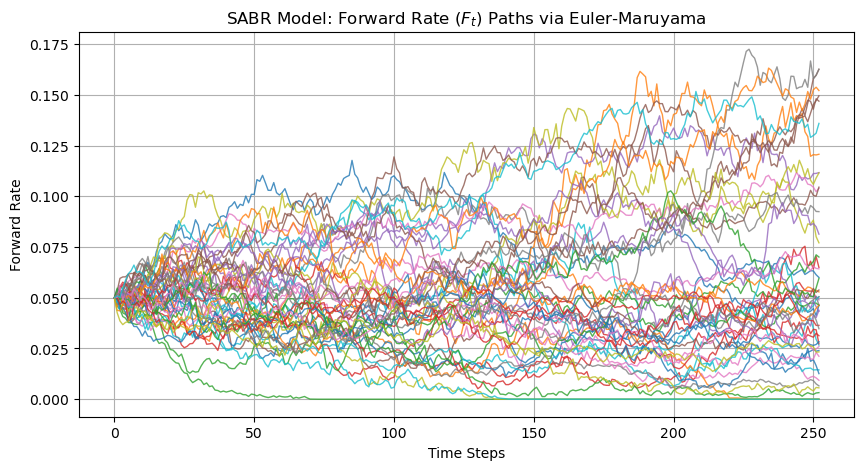

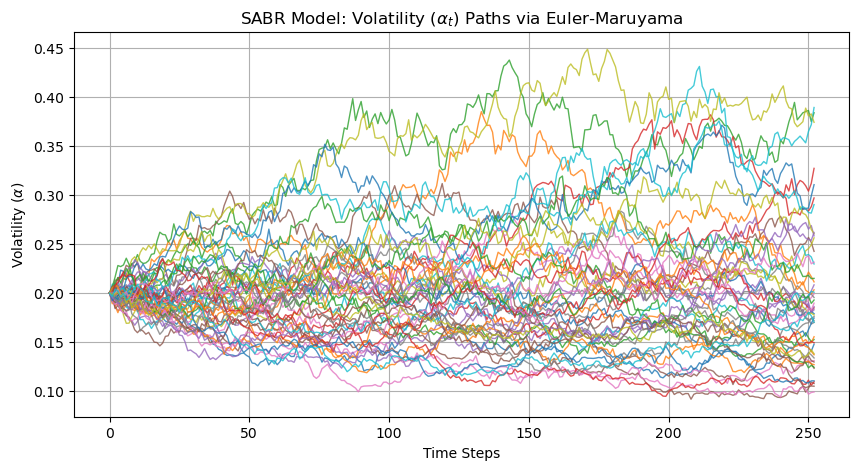

In [ ]:
# Simulation Parameters
F0 = 0.05        # Initial forward rate (e.g., 5%)
alpha0 = 0.20    # Initial volatility parameter
beta = 0.5       # Exponent (0.5 is standard for interest rates)
rho = -0.4       # Correlation (Negative means skew)
nu = 0.4         # Volatility of volatility (Creates the smile curvature)
T = 1.0          # Time horizon in years
N_steps = 252    # Number of discrete time steps (e.g., trading days in a year)
M_paths = 10000  # Number of Monte Carlo paths to simulate

# Run the simulation
F_paths, alpha_paths = simulate_sabr_euler_maruyama(F0, alpha0, beta, rho, nu, T, N_steps, M_paths)

# Plotting the Results
# Plot the first 50 paths of the Forward Rate
plt.figure(figsize=(10, 5))
plt.plot(F_paths[:, :50], lw=1, alpha=0.8)
plt.title("SABR Model: Forward Rate ($F_t$) Paths via Euler-Maruyama")
plt.xlabel("Time Steps")
plt.ylabel("Forward Rate")
plt.grid(True)
plt.show()

# Plot the first 50 paths of the Volatility
plt.figure(figsize=(10, 5))
plt.plot(alpha_paths[:, :50], lw=1, alpha=0.8)
plt.title(r"SABR Model: Volatility ($\alpha_t$) Paths via Euler-Maruyama")
plt.xlabel("Time Steps")
plt.ylabel(r"Volatility ($\alpha$)")
plt.grid(True)
plt.show()